In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import taylor

In [35]:

theta = np.linspace(-np.pi/2,np.pi/2,1000)
rows = 4
cols = 19
length = 3.8
height = 0.8
pitch_rows = length/cols
pitch_cols = height/rows

f = 9.8e9
c = 3e8
wv = c/f
k = 2*np.pi/wv

In [37]:
a_m_rows = taylor(M=rows, nbar=4, sll=30)
a_m_cols = taylor(M=cols, nbar=4, sll=30)

n_rows = np.arange(rows)
n_cols = np.arange(cols)

# --- 2. Phase Steering ---
steering_angle_deg = 2
steering_angle_rad = np.deg2rad(steering_angle_deg)

phase_shift_rows = -k * pitch_rows * n_rows * np.sin(steering_angle_rad)
phase_shift_cols = -k * pitch_cols * n_cols * np.sin(steering_angle_rad)

# --- 3. Combine to create complex weights ---
w_rows = a_m_rows * np.exp(1j * phase_shift_rows)
w_cols = a_m_cols * np.exp(1j * phase_shift_cols)


# 2. Use np.arange instead of standard Python range()
# w_rows = np.ones(rows) # when gain of array is same
# w_cols = np.ones(cols) # when gain of array is same

# 3. Reshape arrays to (4, 1) so they can multiply with theta_rad (1000,)
n_rows = n_rows[:, np.newaxis]
w_rows = w_rows[:, np.newaxis]


# 3. Reshape arrays to (4, 1) so they can multiply with theta_rad (1000,)
n_cols = n_cols[:, np.newaxis]
w_cols = w_cols[:, np.newaxis]

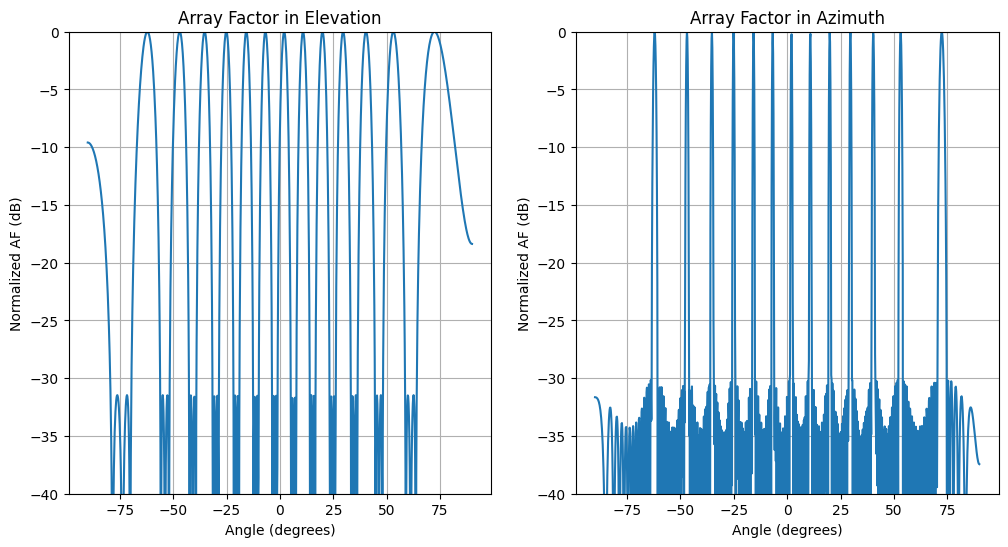

In [38]:
AF_ele = np.sum(w_rows*np.exp(1j*k*n_rows*pitch_rows*np.sin(theta)),axis=0)
AF_azi = np.sum(w_cols*np.exp(1j*k*n_cols*pitch_cols*np.sin(theta)),axis=0)

# Optional: Plotting the result in dB
AF_ele_mag = np.abs(AF_ele)
AF_ele_norm = AF_ele_mag / np.max(AF_ele_mag)
AF_ele_dB = 20 * np.log10(AF_ele_norm + 1e-12) # added small epsilon to avoid log(0)

AF_azi_mag = np.abs(AF_azi)
AF_azi_norm = AF_azi_mag / np.max(AF_azi_mag)
AF_azi_dB = 20 * np.log10(AF_azi_norm + 1e-12) # added small epsilon to avoid log(0)

plt.figure(figsize=[12,6])
plt.subplot(1,2,1)
plt.plot(np.rad2deg(theta), AF_ele_dB)
plt.title("Array Factor in Elevation")
plt.xlabel("Angle (degrees)")
plt.ylabel("Normalized AF (dB)")
plt.ylim(-40, 0)
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(np.rad2deg(theta), AF_azi_dB)
plt.title("Array Factor in Azimuth")
plt.xlabel("Angle (degrees)")
plt.ylabel("Normalized AF (dB)")
plt.ylim(-40, 0)
plt.grid(True)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


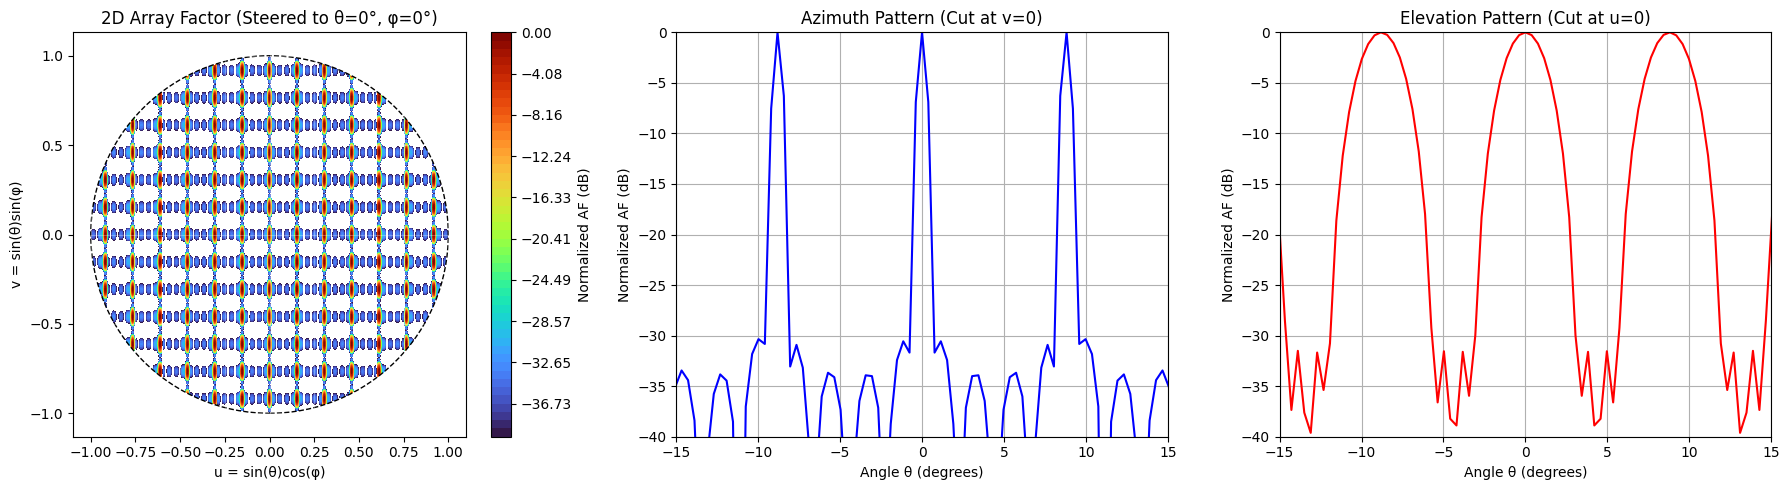

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import taylor

# --- Setup Parameters ---
f = 9.8e9
c = 3e8
wv = c / f
k = 2 * np.pi / wv

cols = 19  # N elements along x
rows = 4   # M elements along y

length = 3.8
height = 0.8
dx = length/cols
dy = height/rows

# --- 1. Amplitude Tapering (2D Taylor Window) ---
# Calculate 1D windows
w_cols_amp = taylor(M=cols, nbar=4, sll=30)
w_rows_amp = taylor(M=rows, nbar=4, sll=30)

# Multiply vectors to get the 2D weight matrix (Outer Product)
W_2D = np.outer(w_rows_amp, w_cols_amp) 

# --- 2. Steering & U-V Space Grid ---
# Steer beam to theta = 30 deg, phi = 45 deg
theta_0 = np.deg2rad(0)
phi_0 = np.deg2rad(0)
u_0 = np.sin(theta_0) * np.cos(phi_0)
v_0 = np.sin(theta_0) * np.sin(phi_0)


# Create a grid of observation angles
# FIX: Use 301 points so index 150 is EXACTLY 0.0 for a perfect center cut
u = np.linspace(-1, 1, 301)
v = np.linspace(-1, 1, 301)
U, V = np.meshgrid(u, v)
center_idx = 150 # The exact middle index

# --- 3. Calculate 2D Array Factor ---
AF_2D = np.zeros_like(U, dtype=complex)

for m in range(rows):
    for n in range(cols):
        phase = k * (n * dx * (U - u_0) + m * dy * (V - v_0))
        AF_2D += W_2D[m, n] * np.exp(1j * phase)

# Convert to Normalized dB
AF_mag = np.abs(AF_2D)
AF_norm = AF_mag / np.max(AF_mag)
AF_dB = 20 * np.log10(AF_norm + 1e-12)

# Mask out the non-physical region (where u^2 + v^2 > 1)
visible_region = (U**2 + V**2) <= 1
AF_dB[~visible_region] = np.nan 

# Convert the u/v grid coordinates back into degrees for the 1D plots
angles_deg = np.rad2deg(np.arcsin(np.clip(u, -1, 1)))

# --- Plotting ---
plt.figure(figsize=(18, 5))

# 1. 2D Heatmap
plt.subplot(1, 3, 1)
contour = plt.contourf(U, V, AF_dB, levels=np.linspace(-40, 0, 50), cmap='turbo')
plt.colorbar(contour, label="Normalized AF (dB)")
circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
plt.gca().add_patch(circle)
plt.title(f"2D Array Factor (Steered to θ={np.rad2deg(theta_0):.0f}°, φ={np.rad2deg(phi_0):.0f}°)")
plt.xlabel("u = sin(θ)cos(φ)")
plt.ylabel("v = sin(θ)sin(φ)")
plt.axis('equal')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.grid(color='white', alpha=0.3)

# 2. Azimuth Cut (Horizontal slice across the center: V = 0)
plt.subplot(1, 3, 2)
# We plot the row at center_idx
plt.plot(angles_deg, AF_dB[center_idx, :], color='blue')
plt.title("Azimuth Pattern (Cut at v=0)")
plt.xlabel("Angle θ (degrees)")
plt.ylabel("Normalized AF (dB)")
plt.ylim(-40, 0)
plt.xlim(-15, 15)
plt.grid(True)

# 3. Elevation Cut (Vertical slice across the center: U = 0)
plt.subplot(1, 3, 3)
# We plot the column at center_idx
plt.plot(angles_deg, AF_dB[:, center_idx], color='red')
plt.title("Elevation Pattern (Cut at u=0)")
plt.xlabel("Angle θ (degrees)")
plt.ylabel("Normalized AF (dB)")
plt.ylim(-40, 0)
plt.xlim(-15, 15)
plt.grid(True)

plt.tight_layout()
plt.show()
